# UAV Agricultural Navigation — Standalone Final Results

**Project version:** 2026.06.22  
**Purpose:** present the complete project outcome in one submission-ready notebook.

All data loading, aggregation, independent validation, and visualization code used by this notebook is written directly in its cells. It does not import any project module from `src/`, `scripts/`, or `pipeline/`.

In [1]:
from pathlib import Path
import json

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from IPython.display import display
from rasterio.enums import Resampling
from shapely.ops import unary_union

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda value: f'{value:,.4f}')

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

required_anchor = ROOT / 'outputs' / 'cpp_targeted' / 'targeted_cpp_metrics.json'
assert required_anchor.exists(), f'Project root or final output not found: {ROOT}'
print(f'Project root: {ROOT}')

Project root: C:\Users\ROG\Desktop\uav_navigation_project


## 1. Load the Complete Project Results

This cell loads the stage manifest, Experiment A/B/C/D results, final mission metrics, route geometry, waypoints, target regions, safe area, and base raster. No hidden project function is called.

In [2]:
def load_json(relative_path):
    path = ROOT / relative_path
    return json.loads(path.read_text(encoding='utf-8'))

manifest = load_json('pipeline/pipeline_manifest.json')
experiment_a = load_json('outputs/cpp_geometry_only/cpp_metrics.json')
experiment_b = load_json('outputs/cpp_risk_aware/risk_aware_metrics.json')
experiment_c = load_json('outputs/extension_early_stage_cpp/early_stage_cpp_metrics.json')
experiment_d_run = load_json('data/experiment_d/run_summary.json')
final_metrics = load_json('outputs/cpp_targeted/targeted_cpp_metrics.json')

seasonal_summary = pd.read_csv(ROOT / 'data/experiment_d/seasonal_summary.csv')
mission_route = gpd.read_file(ROOT / 'outputs/cpp_targeted/mission_route.geojson')
mission_swaths = gpd.read_file(ROOT / 'outputs/cpp_targeted/mission_swaths.geojson')
mission_waypoints = pd.read_csv(ROOT / 'outputs/cpp_targeted/mission_waypoints.csv')
safe_area = gpd.read_file(ROOT / 'data/cpp_ready/geometry/safe_area.geojson')
target_regions = gpd.read_file(final_metrics['inputs']['target_safe_regions'])
robot_parameters = final_metrics['robot_parameters']

print('All result artifacts loaded successfully.')

All result artifacts loaded successfully.


## 2. End-to-End Pipeline Status

```text
Raw UAV / external remote-sensing data
  -> data inventory, georeference QC, and alignment
  -> safe operating geometry
  -> Experiment A: geometry-only coverage
  -> Experiment B: risk layer and risk-aware routing
  -> Experiment C: early-stage routing without vegetation
  -> Experiment D: seasonal vegetation targets
  -> final targeted risk-aware robot mission
```

In [3]:
stage_rows = []
for stage_name, stage in manifest['stages'].items():
    stage_rows.append({
        'Stage': stage_name,
        'Experiment': stage.get('experiment'),
        'Ready': stage['ready_to_run'],
        'Complete': stage['outputs_complete'],
        'Requires network': stage['requires_network'],
        'Missing inputs': ', '.join(stage['missing_inputs']) or 'None',
    })

stage_table = pd.DataFrame(stage_rows)
display(stage_table.style.set_caption('Configured Pipeline Stages'))

complete_count = int(stage_table['Complete'].sum())
stage_count = len(stage_table)
assert complete_count == stage_count
print(f'Pipeline completion: {complete_count}/{stage_count} stages COMPLETE')

,Stage,Experiment,Ready,Complete,Requires network,Missing inputs
0,data_foundation,foundation,True,True,False,None
1,experiment_a_geometry,A,True,True,False,None
2,experiment_b_risk_layer,B,True,True,False,None
3,experiment_b_risk_aware,B,True,True,False,None
4,experiment_c_early_stage,C,True,True,False,None
5,experiment_d_seasonal,D,True,True,True,None
6,final_targeted_mission,mission,True,True,False,None


Pipeline completion: 7/7 stages COMPLETE


## 3. Final Mission — Main Results

In [4]:
mission = final_metrics['mission']
main_results = pd.DataFrame([
    {'Metric': 'Mission status', 'Value': final_metrics['status'], 'Unit': ''},
    {'Metric': 'Selected seasonal target', 'Value': final_metrics['season'], 'Unit': ''},
    {'Metric': 'Safe-area size', 'Value': float(unary_union(safe_area.geometry).area), 'Unit': 'm2'},
    {'Metric': 'Target area', 'Value': final_metrics['target_area_m2'], 'Unit': 'm2'},
    {'Metric': 'Planned fields', 'Value': mission['planned_field_count'], 'Unit': 'fields'},
    {'Metric': 'Coverage swaths', 'Value': mission['swath_count'], 'Unit': 'swaths'},
    {'Metric': 'Route length', 'Value': mission['path_length_m'], 'Unit': 'm'},
    {'Metric': 'Estimated duration', 'Value': mission['estimated_duration_min'], 'Unit': 'min'},
    {'Metric': 'Route outside safe area', 'Value': mission['outside_safe_area'], 'Unit': ''},
    {'Metric': 'Separate-field reposition events', 'Value': mission['separate_field_repositions'], 'Unit': 'events'},
])
display(main_results.style.set_caption('Final Mission Key Performance Indicators'))

field_rows = []
for field_id, field in final_metrics['fields'].items():
    if field.get('status') != 'PLANNED':
        continue
    field_rows.append({
        'Field': field_id,
        'Target area (m2)': field['target_area_m2'],
        'Swaths': field['swath_count'],
        'Path length (m)': field['path_length_m'],
        'Coverage ratio': field['coverage_ratio'],
        'Mean path risk': field['mean_path_risk'],
        'P90 path risk': field['P90_path_risk'],
        'Outside safe area': field['outside_safe_area'],
    })
field_table = pd.DataFrame(field_rows)
display(field_table.style.format({'Coverage ratio': '{:.2%}'}).set_caption('Per-Field Final Results'))

,Metric,Value,Unit
0,Mission status,FINAL_TARGETED_MISSION_COMPLETED,
1,Selected seasonal target,T4_late,
2,Safe-area size,14666.431694,m2
3,Target area,3269.667837,m2
4,Planned fields,2,fields
5,Coverage swaths,204,swaths
6,Route length,3333.937184,m
7,Estimated duration,111.131239,min
8,Route outside safe area,False,
9,Separate-field reposition events,1,events


,Field,Target area (m2),Swaths,Path length (m),Coverage ratio,Mean path risk,P90 path risk,Outside safe area
0,field_01,2011.530295,137,2051.393075,93.84%,0.290292,0.503023,False
1,field_02,1258.137542,67,1282.544109,95.58%,0.293926,0.517002,False


## 4. Experiment A/B/C/D Summary

In [5]:
# Experiment A: geometry-only coverage
a_table = pd.DataFrame(experiment_a['fields'])[[
    'field_id', 'area_m2', 'number_of_swaths', 'approximate_path_length_m',
    'coverage_area_estimate_m2', 'route_crosses_outside_safe_area'
]].rename(columns={
    'field_id': 'Field',
    'area_m2': 'Area (m2)',
    'number_of_swaths': 'Swaths',
    'approximate_path_length_m': 'Path length (m)',
    'coverage_area_estimate_m2': 'Estimated covered area (m2)',
    'route_crosses_outside_safe_area': 'Outside safe area',
})
display(a_table.style.set_caption('Experiment A — Geometry-Only Coverage'))

# Experiment B: baseline versus risk-aware routing
b_columns = [
    'field_id', 'baseline_path_length_m', 'risk_aware_path_length_m',
    'baseline_mean_path_risk', 'risk_aware_mean_path_risk',
    'baseline_high_risk_waypoint_ratio', 'risk_aware_high_risk_waypoint_ratio',
    'risk_aware_outside_safe_area'
]
b_table = pd.DataFrame(experiment_b['comparison'])[b_columns].rename(columns={
    'field_id': 'Field',
    'baseline_path_length_m': 'Baseline length (m)',
    'risk_aware_path_length_m': 'Risk-aware length (m)',
    'baseline_mean_path_risk': 'Baseline mean risk',
    'risk_aware_mean_path_risk': 'Risk-aware mean risk',
    'baseline_high_risk_waypoint_ratio': 'Baseline high-risk ratio',
    'risk_aware_high_risk_waypoint_ratio': 'Risk-aware high-risk ratio',
    'risk_aware_outside_safe_area': 'Outside safe area',
})
display(b_table.style.set_caption('Experiment B — Risk-Aware Comparison'))

# Experiment C: early-stage row-aware routing
c_rows = []
for field_id, field in experiment_c['fields'].items():
    result = field['early_stage_row_aware']
    c_rows.append({
        'Field': field_id,
        'Swaths': result['number_of_swaths'],
        'Path length (m)': result['path_length_m'],
        'Mean path risk': result['mean_path_risk'],
        'Row alignment score': result['row_alignment_score'],
        'Outside safe area': result['outside_safe_area'],
    })
display(pd.DataFrame(c_rows).style.set_caption('Experiment C — Early-Stage Routing'))

# Experiment D: seasonal vegetation targets
d_table = seasonal_summary[[
    'stage', 'date', 'source', 'mean_ndvi', 'mean_vegetation_need',
    'target_polygon_count', 'total_target_area_m2', 'target_area_percentage'
]].rename(columns={
    'stage': 'Stage',
    'date': 'Date',
    'source': 'Source',
    'mean_ndvi': 'Mean NDVI',
    'mean_vegetation_need': 'Mean vegetation need',
    'target_polygon_count': 'Target polygons',
    'total_target_area_m2': 'Target area (m2)',
    'target_area_percentage': 'Target area (%)',
})
display(d_table.style.set_caption('Experiment D — Seasonal Target Statistics'))

,Field,Area (m2),Swaths,Path length (m),Estimated covered area (m2),Outside safe area
0,field_01,9939.614873,58,8399.244884,9916.178585,False
1,field_02,4726.816821,36,3996.101193,4711.995012,False


,Field,Baseline length (m),Risk-aware length (m),Baseline mean risk,Risk-aware mean risk,Baseline high-risk ratio,Risk-aware high-risk ratio,Outside safe area
0,field_01,8399.244884,8403.671220,0.296490,0.296402,0.093458,0.091743,False
1,field_02,3996.101193,3991.179020,0.295827,0.295845,0.081967,0.081967,False


,Field,Swaths,Path length (m),Mean path risk,Row alignment score,Outside safe area
0,field_01,62,4150.354465,0.336099,1.000000,False
1,field_02,60,2237.138791,0.321511,1.000000,False


,Stage,Date,Source,Mean NDVI,Mean vegetation need,Target polygons,Target area (m2),Target area (%)
0,T1_early,2024-04-23,local_ndvi,0.518426,0.384147,4,3325.996622,22.677613
1,T2_anchor,2024-05-28,local_multiband_ms,0.541565,0.656052,2,353.060288,2.407268
2,T3_mid,2024-07-27,local_ndvi,0.486852,0.519912,4,3190.341315,21.752676
3,T4_late,2024-08-21,local_ndvi,0.456611,0.558934,4,3269.667837,22.293547


## 5. Final Mission Map

The visualization is generated directly below from the base raster, safe-area geometry, selected seasonal targets, and final route. The plot does not use a pre-rendered project image.

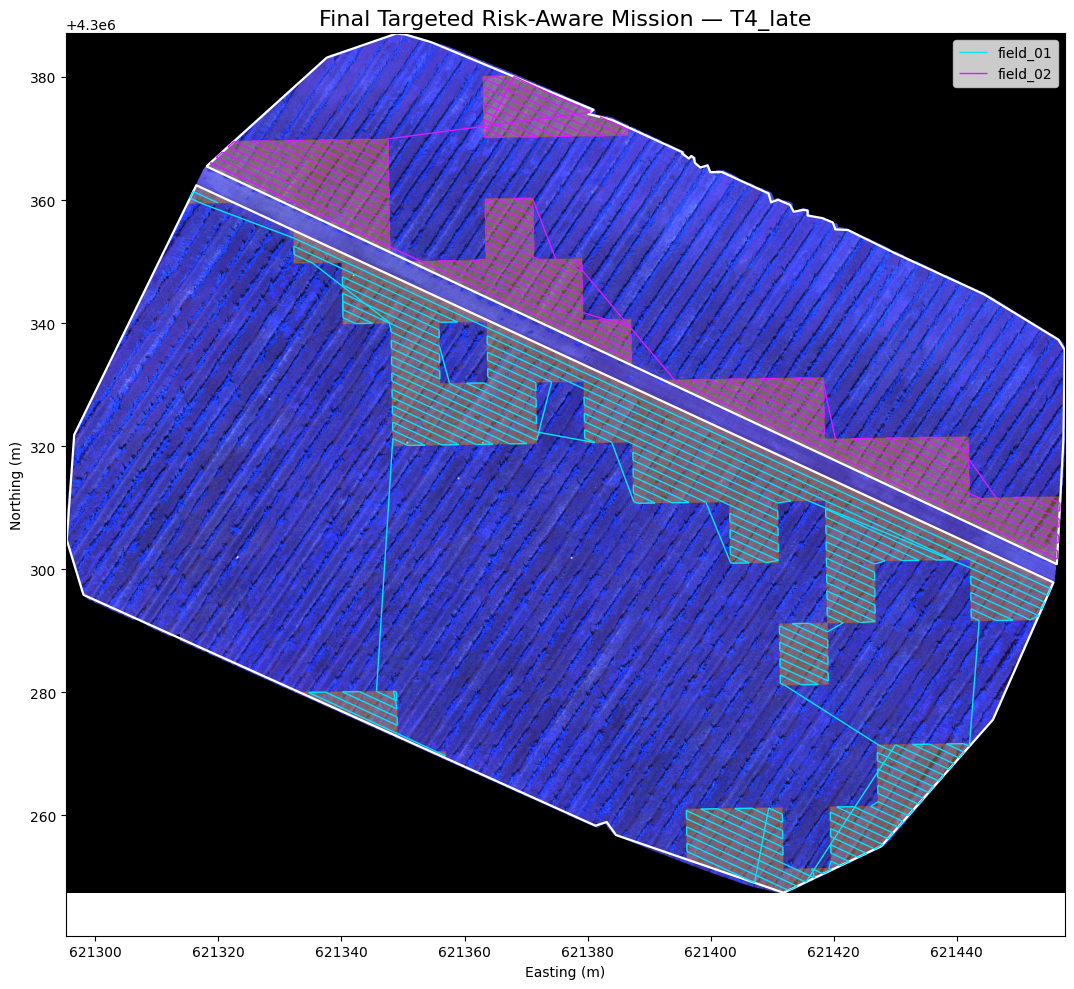

In [6]:
def read_rgb_preview(raster_path, max_dimension=1800):
    with rasterio.open(raster_path) as src:
        scale = max(1, int(np.ceil(max(src.width, src.height) / max_dimension)))
        out_height = max(1, src.height // scale)
        out_width = max(1, src.width // scale)
        indexes = list(range(1, min(3, src.count) + 1))
        data = src.read(
            indexes,
            out_shape=(len(indexes), out_height, out_width),
            resampling=Resampling.bilinear,
        ).astype('float32')
        extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
        crs = src.crs
    if data.shape[0] == 1:
        data = np.repeat(data, 3, axis=0)
    rgb = np.moveaxis(data[:3], 0, -1)
    finite = rgb[np.isfinite(rgb)]
    if finite.size:
        low, high = np.nanpercentile(finite, [2, 98])
        if high > low:
            rgb = np.clip((rgb - low) / (high - low), 0, 1)
    return rgb, extent, crs

base_map_path = ROOT / 'data/processed/base/base_map.tif'
rgb, extent, map_crs = read_rgb_preview(base_map_path)

safe_plot = safe_area.to_crs(map_crs)
target_plot = target_regions.to_crs(map_crs)
route_plot = mission_route.to_crs(map_crs)

fig, ax = plt.subplots(figsize=(14, 10))
ax.imshow(rgb, extent=extent, origin='upper')
target_plot.plot(ax=ax, color='#ffb000', edgecolor='#d95f02', alpha=0.35)
safe_plot.boundary.plot(ax=ax, color='white', linewidth=1.6)

field_colors = {'field_01': '#00e5ff', 'field_02': '#d81bff'}
for field_id, group in route_plot.groupby('field_id'):
    group.plot(ax=ax, color=field_colors.get(field_id, '#7cff00'), linewidth=1.0, label=field_id)

ax.set_title(f"Final Targeted Risk-Aware Mission — {final_metrics['season']}", fontsize=16)
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
ax.set_aspect('equal')
ax.legend(loc='best')
fig.tight_layout()
plt.show()

## 6. Independent Safety and Integrity Validation

In [7]:
route_for_check = mission_route.to_crs(safe_area.crs)
safe_union = unary_union(safe_area.geometry).buffer(1e-7)

expected_outputs = {
    'Projected mission route': ROOT / 'outputs/cpp_targeted/mission_route.geojson',
    'WGS84 mission route': ROOT / 'outputs/cpp_targeted/mission_route_wgs84.geojson',
    'Mission waypoints': ROOT / 'outputs/cpp_targeted/mission_waypoints.csv',
    'Mission swaths': ROOT / 'outputs/cpp_targeted/mission_swaths.geojson',
    'Mission manifest': ROOT / 'outputs/cpp_targeted/mission_manifest.json',
    'Final metrics': ROOT / 'outputs/cpp_targeted/targeted_cpp_metrics.json',
}

validation = {
    'All seven pipeline stages complete': all(stage['outputs_complete'] for stage in manifest['stages'].values()),
    'All final output files exist': all(path.exists() for path in expected_outputs.values()),
    'Mission route is non-empty': not mission_route.empty,
    'Mission waypoints are non-empty': not mission_waypoints.empty,
    'All route segments remain inside safe_area': all(safe_union.covers(geom) for geom in route_for_check.geometry),
    'Mission route order is unique': bool(mission_route['mission_order'].is_unique),
    'Waypoint order is unique': bool(mission_waypoints['mission_waypoint_index'].is_unique),
    'WGS84 waypoint coordinates are complete': bool(mission_waypoints[['longitude', 'latitude']].notna().all().all()),
    'Fields remain separated': set(mission_route['field_id']) == {'field_01', 'field_02'},
}

validation_table = pd.DataFrame([
    {'Validation check': check, 'Passed': passed}
    for check, passed in validation.items()
])
display(validation_table.style.set_caption('Independent Final Validation'))
assert all(validation.values()), 'At least one final validation check failed.'
print('FINAL VALIDATION: ALL CHECKS PASSED')

,Validation check,Passed
0,All seven pipeline stages complete,True
1,All final output files exist,True
2,Mission route is non-empty,True
3,Mission waypoints are non-empty,True
4,All route segments remain inside safe_area,True
5,Mission route order is unique,True
6,Waypoint order is unique,True
7,WGS84 waypoint coordinates are complete,True
8,Fields remain separated,True


FINAL VALIDATION: ALL CHECKS PASSED


## 7. Submission Artifacts

In [8]:
submission_files = {
    'Standalone final-results notebook': ROOT / 'notebooks/06_standalone_final_results.ipynb',
    **expected_outputs,
}

submission_table = pd.DataFrame([
    {
        'Artifact': label,
        'Relative path': str(path.relative_to(ROOT)),
        'Exists': path.exists(),
        'Size (KB)': round(path.stat().st_size / 1024, 1) if path.exists() else None,
    }
    for label, path in submission_files.items()
])
display(submission_table.style.set_caption('Recommended Submission Package'))

,Artifact,Relative path,Exists,Size (KB)
0,Standalone final-results notebook,notebooks\06_standalone_final_results.ipynb,True,17.900000
1,Projected mission route,outputs\cpp_targeted\mission_route.geojson,True,211.800000
2,WGS84 mission route,outputs\cpp_targeted\mission_route_wgs84.geojson,True,204.700000
3,Mission waypoints,outputs\cpp_targeted\mission_waypoints.csv,True,108.400000
4,Mission swaths,outputs\cpp_targeted\mission_swaths.geojson,True,59.200000
5,Mission manifest,outputs\cpp_targeted\mission_manifest.json,True,2.600000
6,Final metrics,outputs\cpp_targeted\targeted_cpp_metrics.json,True,5.100000


## 8. Final Conclusion

The project has a complete seven-stage software pipeline from geospatial UAV data to a seasonal targeted robot mission. The final `T4_late` mission covers two physically separated fields, contains 204 working swaths, has a total planned length of approximately 3.334 km, and passes the independent safe-area and ordering checks.

The final mission is a research-grade planning result. Before real deployment, the prototype robot parameters must be replaced with measured values, field and forbidden-area geometries must be manually confirmed, and the route must pass a supervised low-speed field test.